In [2]:
import torch

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected.")

PyTorch Version: 2.11.0+cu128
CUDA Available: True
GPU Name: Tesla T4


In [3]:
import zipfile
import os

zip_path = "/content/data.zip"
extract_path = "/content/data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted successfully!")

✅ Dataset extracted successfully!


In [4]:
import shutil
import os

source = "/content/data/data"
destination = "/content/data"

# Move all files and folders from /content/data/data to /content/data
for item in os.listdir(source):
    shutil.move(os.path.join(source, item), destination)

# Remove the empty inner data folder
os.rmdir(source)

print("✅ Folder structure fixed!")

✅ Folder structure fixed!


In [5]:
import os

print(os.listdir("/content/data"))

['train_features', 'test_features', 'submission_format.csv', 'train_features.csv', 'train_labels.csv', 'test_features.csv']


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

import torch
from torchvision import transforms

from sklearn.model_selection import train_test_split

In [7]:
DATA_DIR = Path("/content/data")

TRAIN_FEATURES = DATA_DIR / "train_features.csv"
TRAIN_LABELS = DATA_DIR / "train_labels.csv"
TEST_FEATURES = DATA_DIR / "test_features.csv"

TRAIN_IMAGES = DATA_DIR / "train_features"
TEST_IMAGES = DATA_DIR / "test_features"

In [8]:
train_features = pd.read_csv(TRAIN_FEATURES)
train_labels = pd.read_csv(TRAIN_LABELS)
test_features = pd.read_csv(TEST_FEATURES)

print(train_features.shape)
print(train_labels.shape)
print(test_features.shape)

(16488, 3)
(16488, 9)
(4464, 3)


In [9]:
# ===========================================
# Merge Features and Labels
# ===========================================

train_df = train_features.merge(train_labels, on="id")

print(train_df.shape)

train_df.head()

(16488, 11)


,id,filepath,site,antelope_duiker,bird,blank,civet_genet,hog,leopard,monkey_prosimian,rodent
0,ZJ000000,train_features/ZJ000000.jpg,S0120,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ZJ000001,train_features/ZJ000001.jpg,S0069,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,ZJ000002,train_features/ZJ000002.jpg,S0009,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ZJ000003,train_features/ZJ000003.jpg,S0008,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,ZJ000004,train_features/ZJ000004.jpg,S0036,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [10]:
# ===========================================
# Create Image Path
# ===========================================

train_df["image_path"] = train_df["filepath"].apply(
    lambda x: DATA_DIR / x
)

train_df[["filepath", "image_path"]].head()

,filepath,image_path
0,train_features/ZJ000000.jpg,/content/data/train_features/ZJ000000.jpg
1,train_features/ZJ000001.jpg,/content/data/train_features/ZJ000001.jpg
2,train_features/ZJ000002.jpg,/content/data/train_features/ZJ000002.jpg
3,train_features/ZJ000003.jpg,/content/data/train_features/ZJ000003.jpg
4,train_features/ZJ000004.jpg,/content/data/train_features/ZJ000004.jpg


In [11]:
# ===========================================
# Create Label Column
# ===========================================

# These are the one-hot encoded class columns
class_names = [
    "antelope_duiker",
    "bird",
    "blank",
    "civet_genet",
    "hog",
    "leopard",
    "monkey_prosimian",
    "rodent"
]

# Convert one-hot encoding to a single label
train_df["label"] = train_df[class_names].idxmax(axis=1)

# Check the result
train_df[["id", "label"]].head()

,id,label
0,ZJ000000,bird
1,ZJ000001,monkey_prosimian
2,ZJ000002,bird
3,ZJ000003,monkey_prosimian
4,ZJ000004,leopard


In [12]:
# ===========================================
# Train Validation Split
# ===========================================

train_data, valid_data = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["label"]
)

print("Training Images :", len(train_data))
print("Validation Images :", len(valid_data))

Training Images : 13190
Validation Images : 3298


In [13]:
# ===========================================
# Label Mapping
# ===========================================

class_names = sorted(train_df["label"].unique())

label_to_idx = {label: idx for idx, label in enumerate(class_names)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

print(label_to_idx)

{'antelope_duiker': 0, 'bird': 1, 'blank': 2, 'civet_genet': 3, 'hog': 4, 'leopard': 5, 'monkey_prosimian': 6, 'rodent': 7}


In [14]:
from torchvision import transforms

In [15]:
# ===========================================
# Image Transformations
# ===========================================

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

valid_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [16]:
sample_image = Image.open(train_df.iloc[0]["image_path"])

print("Original Size:", sample_image.size)

transformed_image = train_transform(sample_image)

print("Tensor Shape:", transformed_image.shape)

Original Size: (960, 540)
Tensor Shape: torch.Size([3, 224, 224])


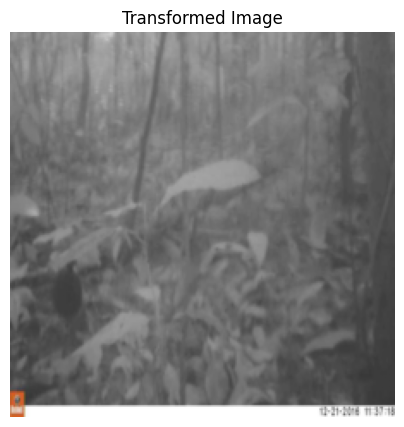

In [17]:
plt.figure(figsize=(5, 5))

plt.imshow(transformed_image.permute(1, 2, 0))

plt.title("Transformed Image")
plt.axis("off")

plt.show()

In [18]:
# ===========================================
# Label Mapping
# ===========================================

class_names = sorted(train_df["label"].unique())

label_to_idx = {
    label: idx
    for idx, label in enumerate(class_names)
}

idx_to_label = {
    idx: label
    for label, idx in label_to_idx.items()
}

print(label_to_idx)

{'antelope_duiker': 0, 'bird': 1, 'blank': 2, 'civet_genet': 3, 'hog': 4, 'leopard': 5, 'monkey_prosimian': 6, 'rodent': 7}


In [19]:
from torch.utils.data import Dataset

In [20]:
# ===========================================
# Custom Dataset
# ===========================================

class WildlifeDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        # Get one row
        row = self.dataframe.iloc[idx]

        # Open image
        image = Image.open(row["image_path"]).convert("RGB")

        # Apply transformations
        if self.transform:
            image = self.transform(image)

        # Convert label to number
        label = label_to_idx[row["label"]]

        return image, label

In [21]:
# ===========================================
# Create Dataset Objects
# ===========================================

train_dataset = WildlifeDataset(
    dataframe=train_data,
    transform=train_transform
)

valid_dataset = WildlifeDataset(
    dataframe=valid_data,
    transform=valid_transform
)

print("Training Images  :", len(train_dataset))
print("Validation Images:", len(valid_dataset))

Training Images  : 13190
Validation Images: 3298


In [22]:
image, label = train_dataset[0]

print("Image Shape :", image.shape)
print("Label Index :", label)
print("Class Name  :", idx_to_label[label])

Image Shape : torch.Size([3, 224, 224])
Label Index : 6
Class Name  : monkey_prosimian


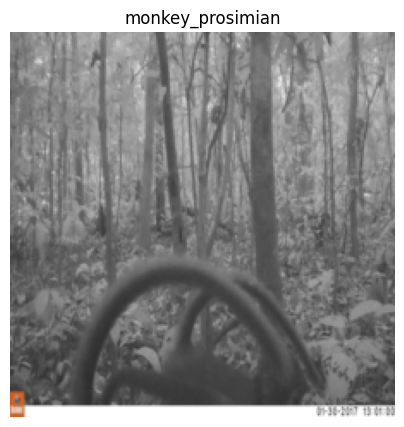

In [23]:
plt.figure(figsize=(5,5))

plt.imshow(image.permute(1,2,0))

plt.title(idx_to_label[label])

plt.axis("off")

plt.show()

In [40]:
# ===========================================
# Create DataLoaders
# ===========================================
from torch.utils.data import DataLoader


BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [25]:
# ===========================================
# Test DataLoader
# ===========================================

images, labels = next(iter(train_loader))

print("Image Batch Shape :", images.shape)
print("Label Batch Shape :", labels.shape)

Image Batch Shape : torch.Size([32, 3, 224, 224])
Label Batch Shape : torch.Size([32])


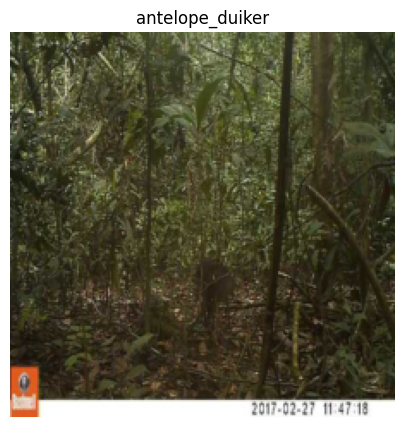

In [26]:
# ===========================================
# Display One Batch Image
# ===========================================

plt.figure(figsize=(5,5))

plt.imshow(images[0].permute(1,2,0))

plt.title(idx_to_label[labels[0].item()])

plt.axis("off")

plt.show()

In [27]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [28]:
# ===========================================
# Import EfficientNet
# ===========================================

from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch.nn as nn

In [29]:
# ===========================================
# Load Pretrained Model
# ===========================================

weights = EfficientNet_B0_Weights.DEFAULT

model = efficientnet_b0(weights=weights)

print(model)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 139MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [30]:
# ===========================================
# Replace Final Classifier
# ===========================================

num_classes = len(class_names)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    num_classes
)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=8, bias=True)
)


In [31]:
# ===========================================
# Move Model to Device
# ===========================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print("Using Device:", device)

Using Device: cuda


In [32]:
# ===========================================
# Loss Function
# ===========================================

criterion = nn.CrossEntropyLoss()

In [35]:
# ===========================================
# Hyperparameters
# ===========================================

EPOCHS = 10
BATCH_SIZE = 32

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

PATIENCE = 3

best_val_acc = 0

In [36]:
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

In [37]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
)

In [43]:
from tqdm.auto import tqdm
import torch

scaler = torch.amp.GradScaler("cuda")


In [44]:
best_val_acc = 0
early_stop_counter = 0

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # ==========================
    # Training
    # ==========================
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    train_bar = tqdm(train_loader, desc="Training")

    for images, labels in train_bar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type="cuda"):

            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

        train_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{100*train_correct/train_total:.2f}%"
        )

    train_acc = 100 * train_correct / train_total
    train_loss /= len(train_loader)

    # ==========================
    # Validation
    # ==========================
    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        val_bar = tqdm(valid_loader, desc="Validation")

        for images, labels in val_bar:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total
    val_loss /= len(valid_loader)

    scheduler.step(val_acc)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.2f}%")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.2f}%")

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(model.state_dict(), "best_model.pth")

        print("✅ Best model saved!")

        early_stop_counter = 0

    else:

        early_stop_counter += 1

        print(f"No improvement ({early_stop_counter}/{PATIENCE})")

    if early_stop_counter >= PATIENCE:

        print("Early stopping!")

        break

print(f"\nBest Validation Accuracy : {best_val_acc:.2f}%")


Epoch 1/10


Training:   0%|          | 0/413 [00:00<?, ?it/s]

Validation:   0%|          | 0/104 [00:00<?, ?it/s]

Train Loss : 0.0746
Train Acc  : 97.38%
Val Loss   : 0.3379
Val Acc    : 91.24%
✅ Best model saved!

Epoch 2/10


Training:   0%|          | 0/413 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/104 [00:00<?, ?it/s]

Train Loss : 0.0426
Train Acc  : 98.65%
Val Loss   : 0.3986
Val Acc    : 91.02%
No improvement (2/3)

Epoch 4/10


Training:   0%|          | 0/413 [00:00<?, ?it/s]

Validation:   0%|          | 0/104 [00:00<?, ?it/s]

Train Loss : 0.0613
Train Acc  : 97.95%
Val Loss   : 0.4446
Val Acc    : 89.90%
No improvement (3/3)
Early stopping!

Best Validation Accuracy : 91.24%


In [45]:
# ===========================================
# Load Best Model
# ===========================================

from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch.nn as nn

weights = EfficientNet_B0_Weights.DEFAULT

model = efficientnet_b0(weights=None)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    len(class_names)
)

model.load_state_dict(torch.load("best_model.pth", map_location=device))

model.to(device)

model.eval()

print("✅ Best model loaded successfully!")

✅ Best model loaded successfully!


In [46]:
# ===========================================
# Test Dataset
# ===========================================

class TestDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.df = dataframe
        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        img_path = self.df.iloc[idx]["image_path"]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image

In [64]:
# ===========================================
# Read Test CSV
# ===========================================

test_df = test_features

test_df["image_path"] = test_df["filepath"].apply(
    lambda x: str(DATA_DIR / x)
)

print(test_df.head())
print(f"Number of test images: {len(test_df)}")

         id                    filepath   site  \
0  ZJ016488  test_features/ZJ016488.jpg  S0082   
1  ZJ016489  test_features/ZJ016489.jpg  S0040   
2  ZJ016490  test_features/ZJ016490.jpg  S0040   
3  ZJ016491  test_features/ZJ016491.jpg  S0041   
4  ZJ016492  test_features/ZJ016492.jpg  S0040   

                                 image_path  
0  /content/data/test_features/ZJ016488.jpg  
1  /content/data/test_features/ZJ016489.jpg  
2  /content/data/test_features/ZJ016490.jpg  
3  /content/data/test_features/ZJ016491.jpg  
4  /content/data/test_features/ZJ016492.jpg  
Number of test images: 4464


In [65]:
test_dataset = TestDataset(
    test_df,
    transform=valid_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

In [66]:
print(class_names)

['antelope_duiker', 'bird', 'blank', 'civet_genet', 'hog', 'leopard', 'monkey_prosimian', 'rodent']


In [67]:
print(test_df["filepath"].head())

0    test_features/ZJ016488.jpg
1    test_features/ZJ016489.jpg
2    test_features/ZJ016490.jpg
3    test_features/ZJ016491.jpg
4    test_features/ZJ016492.jpg
Name: filepath, dtype: object


In [68]:
import torch.nn.functional as F

predictions = []

model.eval()

with torch.no_grad():

    for images in tqdm(test_loader):

        images = images.to(device)

        outputs = model(images)

        probs = F.softmax(outputs, dim=1)

        predictions.extend(probs.cpu().numpy())

print(f"Predictions generated: {len(predictions)}")

  0%|          | 0/140 [00:00<?, ?it/s]

Predictions generated: 4464


In [69]:
# ===========================================
# Create Submission DataFrame
# ===========================================

submission = pd.DataFrame(
    predictions,
    columns=class_names
)

submission.insert(
    0,
    "id",
    test_df["id"]
)

submission.head()

,id,antelope_duiker,bird,blank,civet_genet,hog,leopard,monkey_prosimian,rodent
0,ZJ016488,6.665016e-05,5.287008e-07,3.022879e-01,1.307772e-02,1.988627e-05,0.001021,1.427380e-06,6.835252e-01
1,ZJ016489,9.433564e-01,3.818703e-03,1.853433e-02,4.595209e-04,3.370491e-04,0.000394,3.295927e-02,1.409119e-04
2,ZJ016490,5.902542e-01,2.168045e-05,5.190293e-04,4.087431e-01,2.164762e-05,0.000075,1.033857e-04,2.613719e-04
3,ZJ016491,2.983356e-10,1.543132e-13,3.553092e-08,7.011455e-09,1.283790e-12,1.000000,3.445857e-12,3.760368e-10
4,ZJ016492,9.037960e-03,4.513796e-01,4.809231e-02,1.931681e-02,1.446674e-04,0.165184,3.058345e-01,1.010167e-03


In [70]:
print(submission.shape)
print(submission.columns)

(4464, 9)
Index(['id', 'antelope_duiker', 'bird', 'blank', 'civet_genet', 'hog',
       'leopard', 'monkey_prosimian', 'rodent'],
      dtype='object')


In [71]:
submission.to_csv("submission.csv", index=False)

print("✅ submission.csv saved successfully!")

✅ submission.csv saved successfully!


In [72]:
from google.colab import files

files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>